# 定增项目敏感性分析（通用版本）

## 📌 股票配置区
**修改下方参数来分析不同的定增项目**

| 参数 | 说明 | 光弘科技 | 示例 |
|------|------|----------|------|
| `STOCK_CODE` | 股票代码 | 300735.SZ | 000001.SZ, 600519.SH |
| `STOCK_NAME` | 公司名称 | 光弘科技 | 任意名称 |
| `ISSUE_PRICE` | 发行价格 | 25.0 | 根据定增方案填写 |
| `CURRENT_PRICE` | 当前价格 | 31.25 | 市场最新价 |
| `LOCKUP_PERIOD` | 锁定期（月）| 12 | 通常6/12/18/36 |

---

## 分析目标
本 Notebook 用于分析定增项目对关键参数的敏感性，包括：
- 发行折价率
- 锁定期长度
- 解禁时股价表现
- 破发概率分析

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from utils.analysis_tools import PrivatePlacementRiskAnalyzer

# 直接配置中文字体（适用于vnpy等虚拟环境）
from utils.direct_font_config import setup
setup()

# 获取字体属性（用于绘图时设置字体）
from utils.font_manager import get_font_prop
font_prop = get_font_prop()

%matplotlib inline
sns.set_style('whitegrid')

print('✅ 库导入成功')

✅ 使用字体: Heiti TC
   路径: /System/Library/Fonts/STHeiti Medium.ttc
✅ 使用系统字体: /System/Library/Fonts/STHeiti Medium.ttc
✅ 库导入成功


## 1. 项目参数设置

In [2]:
# ============================================================
# 📌 股票配置说明
# ============================================================
# 
# 现在所有配置都通过 config_loader 自动加载，包括：
# - 定增参数（从 300735_SZ_placement_params.json）
# - 市场数据（从 300735_SZ_market_data.json）
#
# 发行价会按以下优先级确定：
# 1. 真实定增发行价（如果Tushare有数据）
# 2. MA30的8折（当前使用的方式）
# 3. 当前价的8折（回退方案）
#
# 如需分析其他股票，请运行：
#   python fetch_gh_data.py --stock 000001.SZ
#
print("✅ 配置将通过 config_loader 自动加载")
print("   请运行下一个cell")

✅ 配置将通过 config_loader 自动加载
   请运行下一个cell


In [3]:
# ============================================================
# 加载定增分析配置（使用真实数据）
# ============================================================
from utils.config_loader import load_placement_config, print_config_summary

# 加载配置（自动尝试使用真实市场数据）
print("正在加载配置...")
project_params, risk_params, market_data = load_placement_config('300735.SZ')

# 打印配置摘要
print_config_summary(project_params, risk_params, market_data)

# 创建分析器
analyzer = PrivatePlacementRiskAnalyzer(**project_params)

正在加载配置...
✅ 已加载定增参数: ../300735_SZ_placement_params.json
✅ 已加载市场数据: ../300735_SZ_market_data.json
   股票: 光弘科技 (300735.SZ)
   分析日期: 20260306
   当前价格: 23.88 元
✅ 使用市场数据中的最新价格: 23.88 元
✅ 使用真实市场数据:
   波动率: 30.63% (60日)
   收益率: -18.75% (60日年化)

📊 定增分析配置

📋 项目参数:
   发行价格: 20.25 元/股
   当前价格: 23.88 元/股
   锁定期: 6 个月
   发行数量: 5,000,000 股
   融资金额: 1.01 亿元
   当前收益率: +17.95% （浮盈）

📌 发行类型判断:
   MA30: 25.31 元
   发行价: 20.25 元
   ✅ 折价发行（有安全边际）
   安全边际: 20.01%

⚠️ 风险参数:
   波动率: 30.63%
   收益率(漂移率): -18.75%
   数据来源: market_data

📈 波动率详情:
   30日: 33.96%
   60日: 30.63%
   120日: 37.13%
   180日: 36.60%


## 2. 盈亏平衡价格敏感性

# 不同期望收益率下的盈亏平衡价格
target_returns = np.linspace(0.05, 0.50, 10)  # 5%到50%的年化收益率
break_even_prices = [analyzer.calculate_break_even_price(r) for r in target_returns]

# 绘制敏感性曲线
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(target_returns * 100, break_even_prices, 'b-', linewidth=2, label='盈亏平衡价格')
ax.axhline(y=PROJECT_PARAMS['issue_price'], color='r', linestyle='--', label='发行价格')
ax.axhline(y=PROJECT_PARAMS['current_price'], color='g', linestyle='--', label='当前价格')

ax.set_xlabel('期望年化收益率 (%)', fontsize=12, fontproperties=font_prop)
ax.set_ylabel('盈亏平衡价格 (元)', fontsize=12, fontproperties=font_prop)
ax.set_title(f'{STOCK_CONFIG["name"]} - 不同收益率要求下的盈亏平衡价格', fontsize=14, fontweight='bold', fontproperties=font_prop)
ax.legend(prop=font_prop)
for label in ax.get_xticklabels():
    label.set_fontproperties(font_prop)
for label in ax.get_yticklabels():
    label.set_fontproperties(font_prop)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 打印关键数据点
print('\n=== 盈亏平衡价格分析 ===')
for ret in [0.10, 0.15, 0.20, 0.25, 0.30]:
    be_price = analyzer.calculate_break_even_price(ret)
    distance = (analyzer.current_price - be_price) / analyzer.current_price
    status = "✅ 安全" if distance > 0 else "⚠️ 风险"
    print(f"{ret*100:.0f}%年化收益率: 盈亏平衡={be_price:.2f}元, 距离当前价={distance*100:+.2f}% {status}")

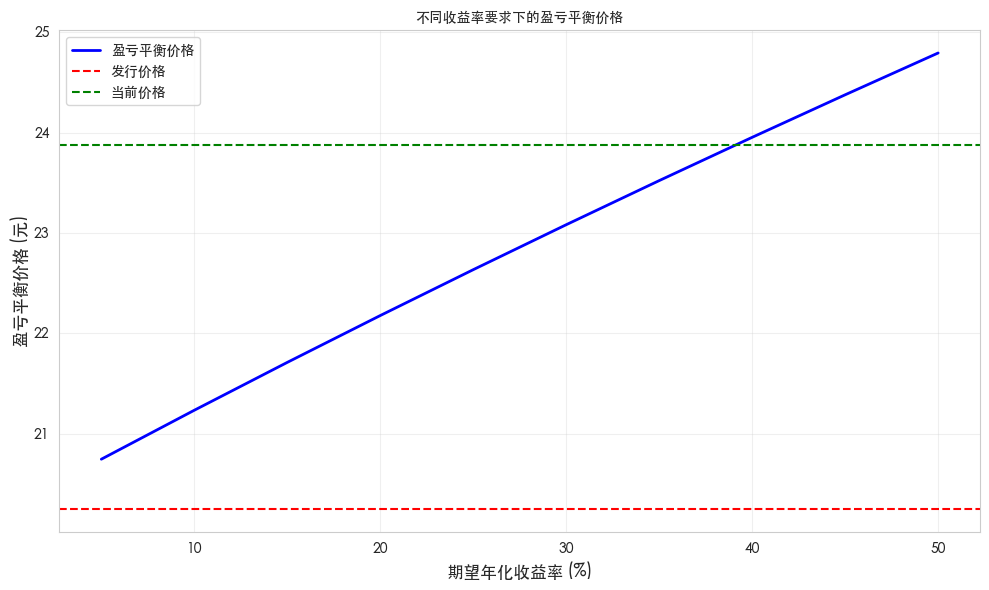


=== 盈亏平衡价格分析 ===
10%年化收益率: 盈亏平衡=21.23元, 距离当前价=11.08%
15%年化收益率: 盈亏平衡=21.71元, 距离当前价=9.09%
20%年化收益率: 盈亏平衡=22.18元, 距离当前价=7.13%
25%年化收益率: 盈亏平衡=22.63元, 距离当前价=5.21%
30%年化收益率: 盈亏平衡=23.08元, 距离当前价=3.34%


In [4]:
# 不同期望收益率下的盈亏平衡价格
target_returns = np.linspace(0.05, 0.50, 10)  # 5%到50%的年化收益率
break_even_prices = [analyzer.calculate_break_even_price(r) for r in target_returns]

# 绘制敏感性曲线
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(target_returns * 100, break_even_prices, 'b-', linewidth=2, label='盈亏平衡价格')
ax.axhline(y=project_params['issue_price'], color='r', linestyle='--', label='发行价格')
ax.axhline(y=project_params['current_price'], color='g', linestyle='--', label='当前价格')

ax.set_xlabel('期望年化收益率 (%)', fontsize=12, fontproperties=font_prop)
ax.set_ylabel('盈亏平衡价格 (元)', fontsize=12, fontproperties=font_prop)
ax.set_title('不同收益率要求下的盈亏平衡价格', fontsize=14, fontweight='bold', fontproperties=font_prop)
ax.legend(prop=font_prop)
for label in ax.get_xticklabels():
    label.set_fontproperties(font_prop)
for label in ax.get_yticklabels():
    label.set_fontproperties(font_prop)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 打印关键数据点
print('\n=== 盈亏平衡价格分析 ===')
for ret in [0.10, 0.15, 0.20, 0.25, 0.30]:
    be_price = analyzer.calculate_break_even_price(ret)
    distance = (analyzer.current_price - be_price) / analyzer.current_price
    print(f"{ret*100:.0f}%年化收益率: 盈亏平衡={be_price:.2f}元, 距离当前价={distance*100:.2f}%")

## 3. 锁定期敏感性分析

In [5]:
# 不同锁定期下的盈亏平衡分析
lockup_periods = [6, 9, 12, 18, 24, 36]  # 不同的锁定期（月）
target_return = 0.20  # 20%年化收益率

lockup_analysis = []
for period in lockup_periods:
    # 修改分析器的锁定期
    analyzer.lockup_period = period
    
    # 计算盈亏平衡价格（20%年化收益率）
    be_price = analyzer.calculate_break_even_price(target_return)
    
    # 计算需要的涨幅
    required_increase = (be_price - analyzer.issue_price) / analyzer.issue_price
    
    lockup_analysis.append({
        'lockup_period': period,
        'break_even_price': be_price,
        'required_increase': required_increase
    })

df_lockup = pd.DataFrame(lockup_analysis)

print('=== 锁定期敏感性分析 ===')
print(f"{'锁定期(月)':<12} {'盈亏平衡价':<15} {'需要涨幅':<12}")
print('-'*40)
for _, row in df_lockup.iterrows():
    print(f"{int(row['lockup_period']):<8} {row['break_even_price']:>10.2f}元     {row['required_increase']*100:>8.2f}%")

=== 锁定期敏感性分析 ===
锁定期(月)       盈亏平衡价           需要涨幅        
----------------------------------------
6             22.18元         9.54%
9             23.21元        14.65%
12            24.29元        20.00%
18            26.61元        31.45%
24            29.15元        44.00%
36            34.98元        72.80%


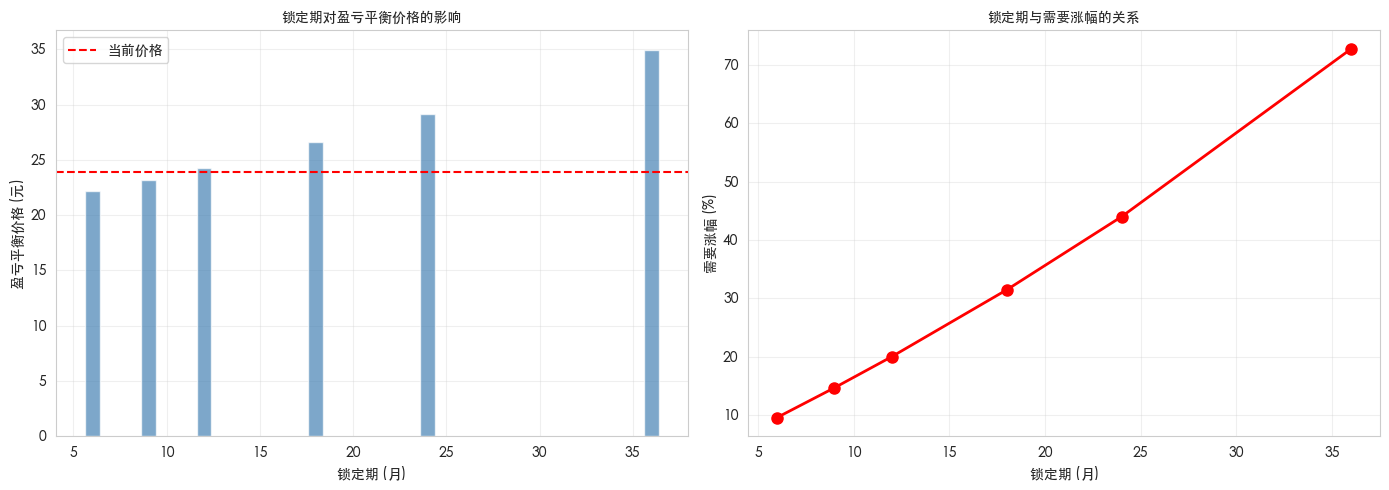

In [6]:
# 可视化
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(df_lockup['lockup_period'], df_lockup['break_even_price'], color='steelblue', alpha=0.7)
ax1.axhline(y=project_params['current_price'], color='r', linestyle='--', label='当前价格')
ax1.set_xlabel('锁定期 (月)', fontproperties=font_prop)
ax1.set_ylabel('盈亏平衡价格 (元)', fontproperties=font_prop)
ax1.set_title('锁定期对盈亏平衡价格的影响', fontproperties=font_prop)
ax1.legend(prop=font_prop)
for label in ax1.get_xticklabels():
    label.set_fontproperties(font_prop)
for label in ax1.get_yticklabels():
    label.set_fontproperties(font_prop)
ax1.grid(True, alpha=0.3)

ax2.plot(df_lockup['lockup_period'], df_lockup['required_increase']*100, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('锁定期 (月)', fontproperties=font_prop)
ax2.set_ylabel('需要涨幅 (%)', fontproperties=font_prop)
ax2.set_title('锁定期与需要涨幅的关系', fontproperties=font_prop)
for label in ax2.get_xticklabels():
    label.set_fontproperties(font_prop)
for label in ax2.get_yticklabels():
    label.set_fontproperties(font_prop)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. 破发概率分析（基于折价/溢价发行）

### 核心逻辑

本分析基于您提出的正确理解：

**发行类型定义**：
- **折价发行**：`issue_price < MA20` → 有安全边际，投资风险较低
- **溢价发行**：`issue_price > MA20` → 无安全边际，投资风险较高

**盈利阈值设定**：
- **折价发行**：盈利阈值 = 发行价（已有安全边际，只需不破发）
- **溢价发行**：盈利阈值 = max(MA20, 发行价×1.02)（需回到合理估值或至少2%收益）

**为什么这样设定？**
1. **折价发行**：发行价低于市场均价，投资者已有价格优势，解禁时只要不低于发行价就算盈利
2. **溢价发行**：发行价高于市场均价，投资者无价格优势，需要股价回归合理估值才算盈利

### 分析说明

- 使用MA30作为MA20的近似（市场数据中可获取）
- 使用真实的60日收益率作为漂移率
- 分析不同波动率下的盈利概率变化

In [7]:
# 基于折价/溢价发行的盈利概率分析
# ============================================================
# 核心逻辑：
# - 折价发行：issue_price < MA20，有安全边际
# - 溢价发行：issue_price > MA20，无安全边际
# ============================================================

# 使用已加载的市场数据
ma20 = market_data['ma_30']  # 使用MA30作为MA20的近似

# 判断发行类型
is_discount = project_params['issue_price'] < ma20
issue_type = "折价发行" if is_discount else "溢价发行"

# 计算盈利阈值
if is_discount:
    # 折价发行：已有安全边际
    # 盈利定义为：解禁价 >= 发行价
    threshold = project_params['issue_price']
    safety_margin = (ma20 - project_params['issue_price']) / ma20 * 100
    print(f"✅ 发行类型: 折价发行（有安全边际）")
    print(f"   MA30价格: {ma20:.2f} 元")
    print(f"   发行价格: {project_params['issue_price']:.2f} 元")
    print(f"   安全边际: {safety_margin:.2f}%")
    print(f"   盈利阈值: {threshold:.2f} 元（发行价）")
else:
    # 溢价发行：无安全边际
    # 盈利定义为：解禁价 >= MA20（回到合理估值）
    # 或者解禁价 >= 发行价 * 1.02（至少2%收益）
    threshold = max(ma20, project_params['issue_price'] * 1.02)
    premium_rate = (project_params['issue_price'] - ma20) / ma20 * 100
    print(f"⚠️ 发行类型: 溢价发行（无安全边际）")
    print(f"   MA30价格: {ma20:.2f} 元")
    print(f"   发行价格: {project_params['issue_price']:.2f} 元")
    print(f"   溢价幅度: {premium_rate:.2f}%")
    print(f"   盈利阈值: {threshold:.2f} 元（max(MA30, 发行价×1.02)）")

print("\n" + "="*60)
print("不同波动率下的盈利概率分析")
print("="*60)

# 不同波动率下的盈利概率分析
volatilities = np.linspace(0.15, 0.60, 10)  # 15%到60%的年化波动率
drift = risk_params['drift']  # 使用真实收益率

prob_analysis = []
for vol in volatilities:
    # 计算锁定期的波动率和收益率
    lockup_vol = vol * np.sqrt(project_params['lockup_period'] / 12)
    lockup_drift = drift * (project_params['lockup_period'] / 12)
    
    # 计算达到阈值需要的收益率
    required_return = (threshold - project_params['current_price']) / project_params['current_price']
    
    # 计算盈利概率（使用正态分布）
    from scipy.stats import norm
    z_score = (lockup_drift - required_return) / lockup_vol
    profit_prob = 1 - norm.cdf(-z_score)  # 盈利概率
    loss_prob = 1 - profit_prob  # 破发概率
    
    prob_analysis.append({
        'volatility': vol,
        'profit_probability': profit_prob,
        'loss_probability': loss_prob,
        'threshold': threshold
    })

# 打印结果表格
print(f"\n{'波动率':<10} {'盈利阈值':<12} {'盈利概率':<12} {'破发概率':<12}")
print('-'*50)
for _, row in pd.DataFrame(prob_analysis).iterrows():
    if row['volatility'] * 100 % 5 == 0:  # 只打印5%倍数的波动率
        print(f"{int(row['volatility']*100):>3}%      {row['threshold']:>8.2f}元     {row['profit_probability']*100:>7.1f}%      {row['loss_probability']*100:>7.1f}%")

df_prob = pd.DataFrame(prob_analysis)

✅ 发行类型: 折价发行（有安全边际）
   MA30价格: 25.31 元
   发行价格: 20.25 元
   安全边际: 20.01%
   盈利阈值: 20.25 元（发行价）

不同波动率下的盈利概率分析

波动率        盈利阈值         盈利概率         破发概率        
--------------------------------------------------
 15%         20.25元        70.9%         29.1%
 20%         20.25元        66.0%         34.0%
 25%         20.25元        63.0%         37.0%
 30%         20.25元        60.9%         39.1%
 35%         20.25元        59.3%         40.7%
 40%         20.25元        58.2%         41.8%
 50%         20.25元        56.6%         43.4%
 60%         20.25元        55.5%         44.5%


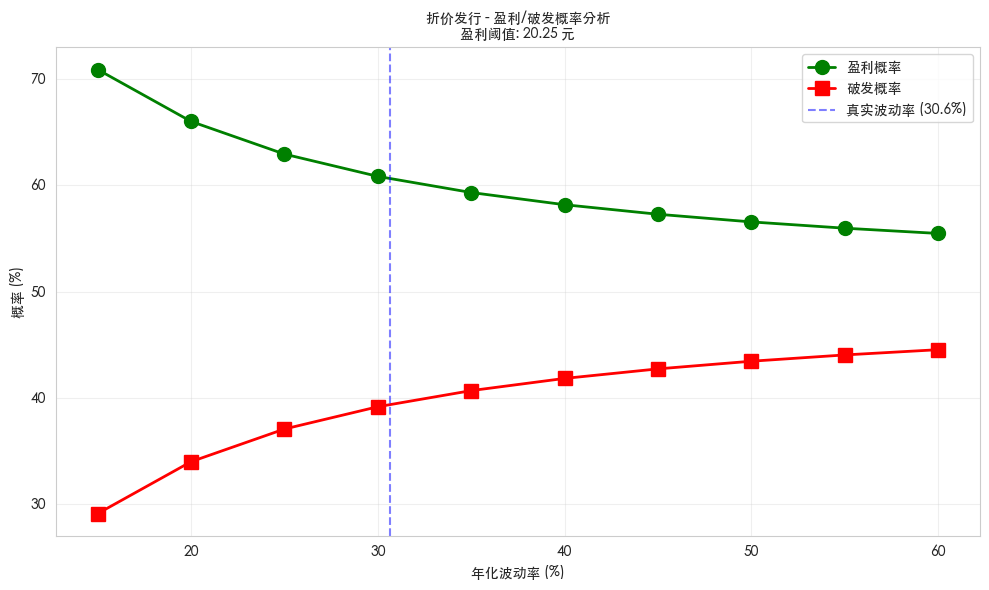

In [8]:
# 可视化
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df_prob['volatility']*100, df_prob['profit_probability']*100, 
        'g-o', linewidth=2, markersize=10, label='盈利概率')
ax.plot(df_prob['volatility']*100, df_prob['loss_probability']*100, 
        'r-s', linewidth=2, markersize=10, label='破发概率')

# 添加参考线：真实波动率
real_vol = risk_params['volatility'] * 100
ax.axvline(x=real_vol, color='b', linestyle='--', alpha=0.5, label=f'真实波动率 ({real_vol:.1f}%)')

ax.set_xlabel('年化波动率 (%)', fontproperties=font_prop)
ax.set_ylabel('概率 (%)', fontproperties=font_prop)
title = f'{issue_type} - 盈利/破发概率分析\n'
title += f'盈利阈值: {df_prob["threshold"].iloc[0]:.2f} 元'
ax.set_title(title, fontsize=14, fontweight='bold', fontproperties=font_prop)
ax.legend(prop=font_prop)
for label in ax.get_xticklabels():
    label.set_fontproperties(font_prop)
for label in ax.get_yticklabels():
    label.set_fontproperties(font_prop)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# 参数敏感性分析（龙卷风图）
# 分析各参数对收益率的影响

# 基准参数
base_params = {
    'issue_price': 20.0,
    'current_price': 18.5,
    'lockup_period': 12,
    'volatility': 0.35,
    'drift': 0.08
}

# 计算基准收益率
def calculate_return_params(params):
    period_years = params['lockup_period'] / 12
    vol_period = params['volatility'] * np.sqrt(period_years)
    drift_period = params['drift'] * period_years
    required_return = (params['current_price'] - params['issue_price']) / params['issue_price']
    z_score = (drift_period - required_return) / vol_period
    from scipy.stats import norm
    profit_prob = 1 - norm.cdf(-z_score)
    return profit_prob

base_return = calculate_return_params(base_params)

# 参数变化分析
param_changes = []
changes = [-0.2, -0.1, 0.1, 0.2]  # ±10%, ±20%

# 1. 发行价格敏感性
for change in changes:
    params = base_params.copy()
    params['issue_price'] = base_params['issue_price'] * (1 + change)
    new_return = calculate_return_params(params)
    impact = (new_return - base_return) * 100
    param_changes.append({'parameter': f'发行价 ({int(change*100)}%)', 'impact_percent': impact})

# 2. 当前价格敏感性
for change in changes:
    params = base_params.copy()
    params['current_price'] = base_params['current_price'] * (1 + change)
    new_return = calculate_return_params(params)
    impact = (new_return - base_return) * 100
    param_changes.append({'parameter': f'当前价 ({int(change*100)}%)', 'impact_percent': impact})

# 3. 锁定期敏感性
for change in changes:
    params = base_params.copy()
    params['lockup_period'] = base_params['lockup_period'] * (1 + change)
    new_return = calculate_return_params(params)
    impact = (new_return - base_return) * 100
    param_changes.append({'parameter': f'锁定期 ({int(change*100)}%)', 'impact_percent': impact})

# 4. 波动率敏感性
for change in changes:
    params = base_params.copy()
    params['volatility'] = base_params['volatility'] * (1 + change)
    new_return = calculate_return_params(params)
    impact = (new_return - base_return) * 100
    param_changes.append({'parameter': f'波动率 ({int(change*100)}%)', 'impact_percent': impact})

# 按影响程度排序
df_tornado = pd.DataFrame(param_changes).sort_values('impact_percent')

print('\n=== 参数敏感性排序（龙卷风图）===')
print(f"{'参数':<25} {'对盈利概率的影响':<15}")
print('-'*40)
for _, row in df_tornado.iterrows():
    print(f"{row['parameter']:<20} {row['impact_percent']:>8.2f}%")


=== 参数敏感性排序（龙卷风图）===
参数                        对盈利概率的影响       
----------------------------------------
发行价 (-20%)             -25.73%
当前价 (20%)              -20.52%
发行价 (-10%)             -11.18%
当前价 (10%)              -10.02%
波动率 (20%)               -2.71%
波动率 (10%)               -1.47%
锁定期 (-10%)              -0.01%
锁定期 (-20%)               0.04%
锁定期 (10%)                0.04%
锁定期 (20%)                0.11%
波动率 (-10%)               1.76%
波动率 (-20%)               3.90%
发行价 (10%)                8.17%
当前价 (-10%)               8.92%
发行价 (20%)               14.04%
当前价 (-20%)              16.33%


## 5. 龙卷风图 - 参数敏感性排序

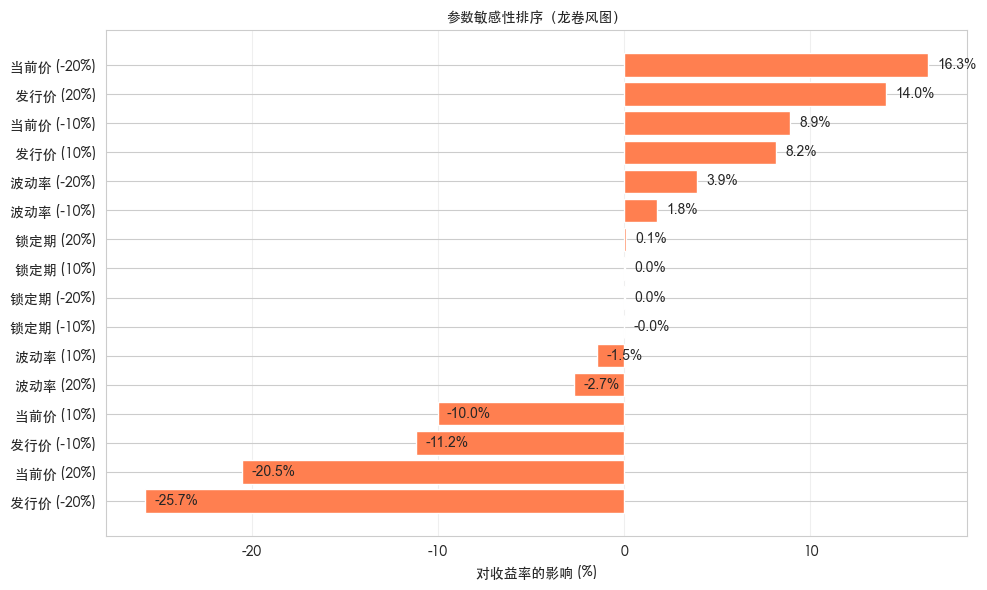

In [10]:
# 绘制龙卷风图
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(df_tornado['parameter'], df_tornado['impact_percent'], color='coral')
ax.set_xlabel('对收益率的影响 (%)', fontproperties=font_prop)
ax.set_title('参数敏感性排序（龙卷风图）', fontsize=14, fontweight='bold', fontproperties=font_prop)
for label in ax.get_yticklabels():
    label.set_fontproperties(font_prop)
for label in ax.get_xticklabels():
    label.set_fontproperties(font_prop)
ax.grid(True, axis='x', alpha=0.3)

# 添加数值标签
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.5, bar.get_y() + bar.get_height()/2,
            f'{width:.1f}%', ha='left', va='center')

plt.tight_layout()
plt.show()

## 6. 敏感性分析结论

In [11]:
print('\n' + '='*50)
print('敏感性分析结论')
print('='*50)
print(f"\n1. 当前价格较发行价: {(analyzer.current_price/analyzer.issue_price - 1)*100:.2f}%")
print(f"\n2. 20%年化收益率要求下的盈亏平衡价: {analyzer.calculate_break_even_price(0.20):.2f}元")
print(f"\n3. 当前价距离盈亏平衡价: {(analyzer.current_price - analyzer.calculate_break_even_price(0.20))/analyzer.current_price*100:.2f}%")
print(f"\n4. 在30%年化波动率假设下，盈利概率约: {df_prob[df_prob['volatility']==0.3]['profit_probability'].values[0]*100:.1f}%")
print(f"\n5. 最敏感的参数是: {df_tornado.iloc[-1]['parameter']}")


敏感性分析结论

1. 当前价格较发行价: 17.95%

2. 20%年化收益率要求下的盈亏平衡价: 34.98元

3. 当前价距离盈亏平衡价: -46.50%

4. 在30%年化波动率假设下，盈利概率约: 60.9%

5. 最敏感的参数是: 当前价 (-20%)


## 7. 净利润增长率敏感性分析

归母净利润增长率是影响股价表现的核心因素之一。本节分析不同净利润增长率情景对定增项目收益的影响。

### 7.1 分析参数

- **增长率范围**：0% 到 50%
- **传导系数**：70%（假设70%的净利润增长会反映在股价上）
- **分析维度**：预期价格、年化收益率、盈利概率


In [ ]:
# 净利润增长率敏感性分析参数
growth_rates = [0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]  # 0%到50%
growth_transmission_coeff = 0.7  # 传导系数70%

print(f'分析参数：')
print(f'  增长率范围: {[f"{g*100:.0f}%" for g in growth_rates]}')
print(f'  传导系数: {growth_transmission_coeff*100:.0f}%')
print(f'  当前价格: {current_price:.2f} 元')
print(f'  发行价格: {issue_price:.2f} 元')
print(f'  锁定期: {lockup_period} 个月')


In [ ]:
# 计算不同增长率情景下的收益
growth_scenarios = []

for growth_rate in growth_rates:
    # 计算预期价格（基于净利润增长传导）
    lockup_years = lockup_period / 12
    expected_price = current_price * (1 + growth_rate * growth_transmission_coeff * lockup_years)
    
    # 计算收益率
    total_return = (expected_price - issue_price) / issue_price
    annualized_return = (1 + total_return) ** (1 / lockup_years) - 1
    
    # 使用蒙特卡洛模拟计算盈利概率
    n_sim = 5000
    lockup_days = lockup_period * 30
    lockup_vol = volatility * np.sqrt(lockup_days / 365)
    growth_drift = drift + (growth_rate * growth_transmission_coeff)
    lockup_drift_period = growth_drift * (lockup_days / 365)
    
    np.random.seed(42)
    sim_returns = np.random.normal(lockup_drift_period, lockup_vol, n_sim)
    final_prices = current_price * np.exp(sim_returns)
    profit_losses = (final_prices - issue_price) / issue_price
    profit_prob = (profit_losses > 0).mean() * 100
    
    growth_scenarios.append({
        'growth_rate': growth_rate,
        'expected_price': expected_price,
        'total_return': total_return,
        'annualized_return': annualized_return,
        'profit_prob': profit_prob
    })

# 创建DataFrame
import pandas as pd
df_growth = pd.DataFrame([{  
    '净利润增长率': f"{s['growth_rate']*100:.0f}%",
    '预期期末价格(元)': f"{s['expected_price']:.2f}",
    '总收益率': f"{s['total_return']*100:.2f}%",
    '年化收益率': f"{s['annualized_return']*100:.2f}%",
    '盈利概率': f"{s['profit_prob']:.1f}%"
} for s in growth_scenarios])

display(df_growth)


In [ ]:
# 可视化：净利润增长率敏感性分析
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

growth_labels = [f'{s["growth_rate"]*100:.0f}%' for s in growth_scenarios]
annual_returns = [s['annualized_return']*100 for s in growth_scenarios]
profit_probs = [s['profit_prob'] for s in growth_scenarios]

# 左图：增长率 vs 年化收益率
ax1 = axes[0]
ax1.plot(growth_labels, annual_returns, marker='o', linewidth=2.5, markersize=8, color='#3498db')
ax1.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax1.axhline(y=20, color='green', linestyle=':', linewidth=1, alpha=0.5, label='20%目标收益线')
ax1.set_xlabel('归母净利润增长率', fontsize=12)
ax1.set_ylabel('年化收益率 (%)', fontsize=12)
ax1.set_title('净利润增长率对年化收益的影响', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

# 右图：增长率 vs 盈利概率
ax2 = axes[1]
colors = ['#e74c3c' if p < 50 else '#f39c12' if p < 70 else '#27ae60' for p in profit_probs]
ax2.bar(growth_labels, profit_probs, color=colors, alpha=0.7, edgecolor='white')
ax2.axhline(y=50, color='black', linestyle='--', linewidth=1, alpha=0.5, label='盈亏平衡线')
ax2.axhline(y=80, color='green', linestyle=':', linewidth=1, alpha=0.5, label='高概率线(80%)')
ax2.set_xlabel('归母净利润增长率', fontsize=12)
ax2.set_ylabel('盈利概率 (%)', fontsize=12)
ax2.set_title('净利润增长率对盈利概率的影响', fontsize=13, fontweight='bold')
ax2.set_ylim(0, 100)
ax2.grid(True, alpha=0.3, axis='y')
ax2.legend()

plt.tight_layout()
plt.savefig('../data/processed/growth_rate_sensitivity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


### 7.2 敏感性分析结论

**关键发现：**

1. **盈亏平衡点**：找出盈利概率达到50%的最低增长率
2. **增长效应**：增长率每提升10%，对年化收益率的影响
3. **投资建议**：基于公司历史增长率和行业前景评估可实现的增长率

**风险提示：**
- 净利润增长受宏观经济、行业竞争等多重因素影响
- 历史增长率不代表未来表现
- 高增长（>30%）通常难以持续
